# Ablation IMV - MNIST / convolutional network

Architectural ablation of a convolutional network on MNIST, scored with the
installed `imvpy` package.

`AblationIMV` currently compares binary probabilistic predictions. MNIST is
therefore modelled as a balanced, interpretable binary task: **odd digit (1)
versus even digit (0)**. The images, canonical 60,000/10,000 split, and standard
MNIST normalization are otherwise unchanged.

The network follows the two-convolution PyTorch MNIST architecture used in the
[seed-sensitivity reference](https://github.com/crahal/seeds/blob/main/src/analysis/build_mnist_seeds.py).
We compare it with four controlled variants, train every variant over ten
seeds, and pass the resulting aligned probabilities to
`AblationIMV.calculate_imv_matrix`.

**Pipeline**: download `mnist_784` from OpenML -> construct odd/even labels ->
train five architectural variants over ten seeds -> calculate and visualize
directional ablation IMV.

This is a new example run, not a replication of a published result. It uses one
epoch as a documented compute budget. Restartable predictions and exported
artifacts are cached outside the repository under `~/.cache/imv`.

In [1]:
import gc
import os
import sys
import tempfile
import time
import warnings
from pathlib import Path
from types import SimpleNamespace

_PATH_DISPLAY_ROOT = Path()

def relative_path(path, *, start=None):
    """Return a display-only path relative to an explicit local anchor."""
    anchor = Path(start) if start is not None else _PATH_DISPLAY_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=anchor.expanduser().resolve())
    except ValueError:  # Paths on different Windows drives cannot be relativized.
        relative = Path(path).name
    return Path(relative).as_posix()

def _relative_warning_text(message):
    text = str(message)
    roots = {Path.home(), Path(sys.prefix), Path(sys.base_prefix),
             _PATH_DISPLAY_ROOT, Path(tempfile.gettempdir())}
    for root in sorted(roots, key=lambda value: len(str(value)), reverse=True):
        absolute = str(root.expanduser().resolve())
        text = text.replace(absolute, relative_path(absolute))
    return text

def _show_relative_warning(message, category, filename, lineno, file=None, line=None):
    stream = file if file is not None else sys.stderr
    warning_text = _relative_warning_text(message)
    print(f"{relative_path(filename)}:{lineno}: {category.__name__}: {warning_text}", file=stream)

warnings.showwarning = _show_relative_warning

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import fetch_openml
from torch.utils.data import DataLoader, Dataset
from joblib import Parallel, delayed, parallel_config
from tqdm.auto import tqdm

import imvpy
from imvpy import AblationIMV, information_deficit, ll

IMVPY_SOURCE = Path(imvpy.__file__).resolve().parent

CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
DATA_HOME = Path(os.environ.get("IMV_DATA_CACHE", CACHE / "datasets")) / "openml"
ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")) / "ablation_imv_mnist"
RESULTS = ARTIFACTS / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "requirements.txt").is_file() and (path / "src").is_dir()),
    Path.cwd(),
)
FIGURES = Path(os.environ.get(
    "IMV_FIGURE_DIR", PROJECT_ROOT / "output" / "figures"
))
FIGURES.mkdir(parents=True, exist_ok=True)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
from figure_utils import (
    COLORMAP, configure_plotting, spectral_colors, plot_ablation_matrix,
    save_publication_figure as save_figure,
)
configure_plotting()
FORCE_RECOMPUTE = os.environ.get("IMV_FORCE_RECOMPUTE", "0").strip().lower() in {
    "1", "true", "yes",
}

SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]  # ten complete runs
BATCH, TEST_BATCH, EPOCHS, LR = 256, 1000, 1, 1.0
CPU_COUNT = (len(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity")
             else (os.cpu_count() or 1))
TORCH_THREADS = min(4, CPU_COUNT)
torch.set_num_threads(TORCH_THREADS)

# Constructing AblationIMV delegates device selection to the package.
ablator = AblationIMV(random_seed=SEEDS[0])
DEFAULT_TORCH_JOBS = min(6, max(1, CPU_COUNT // TORCH_THREADS), len(SEEDS))
REQUESTED_TORCH_JOBS = int(os.environ.get("IMV_TORCH_JOBS", DEFAULT_TORCH_JOBS))
if REQUESTED_TORCH_JOBS < 1:
    raise ValueError("IMV_TORCH_JOBS must be a positive integer")
TORCH_N_JOBS = (min(REQUESTED_TORCH_JOBS, len(SEEDS),
                    max(1, CPU_COUNT // TORCH_THREADS))
                if ablator.device.type == "cpu" else 1)
print(f"imvpy {imvpy.__version__} from {relative_path(IMVPY_SOURCE)}")
print("package class:", f"{AblationIMV.__module__}.{AblationIMV.__name__}")

Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
imvpy 1.2.0 from ../../../../../../../../anaconda3/lib/python3.12/site-packages/imvpy
package class: imvpy.ablation_imv.evaluator.AblationIMV


## 1. Download and preprocess

`mnist_784` version 1 is fetched from OpenML into `~/.cache/imv/datasets/openml`
(or `IMV_DATA_CACHE/openml` when set). Nothing is stored in the repository. OpenML
preserves the canonical ordering: the first 60,000 rows are the training split
and the final 10,000 are the test split.

Pixel values are normalized with the standard MNIST mean `0.1307` and standard
deviation `0.3081`, matching the reference implementation. The original digit
labels remain available for audit; the model target is `digit % 2`.

In [2]:
pixels, digit_labels = fetch_openml(
    "mnist_784", version=1, return_X_y=True, as_frame=False, data_home=DATA_HOME
)
pixels = np.asarray(pixels, dtype=np.float32).reshape(-1, 1, 28, 28)
pixels = (pixels / 255.0 - 0.1307) / 0.3081
digit_labels = np.asarray(digit_labels, dtype=np.int64)
binary_labels = (digit_labels % 2).astype(np.int64)

assert pixels.shape == (70_000, 1, 28, 28)
assert digit_labels.shape == binary_labels.shape == (70_000,)

train_images = torch.from_numpy(pixels[:60_000])
test_images = torch.from_numpy(pixels[60_000:])
train_labels = torch.from_numpy(binary_labels[:60_000])
test_labels = torch.from_numpy(binary_labels[60_000:])

print("raw shape:", pixels.shape)
print("digit counts:", dict(zip(*np.unique(digit_labels, return_counts=True))))
print("train shape:", tuple(train_images.shape),
      "odd/even:", dict(zip(*np.unique(train_labels.numpy(), return_counts=True))))
print("test shape:", tuple(test_images.shape),
      "odd/even:", dict(zip(*np.unique(test_labels.numpy(), return_counts=True))))

raw shape: (70000, 1, 28, 28)
digit counts: {0: 6903, 1: 7877, 2: 6990, 3: 7141, 4: 6824, 5: 6313, 6: 6876, 7: 7293, 8: 6825, 9: 6958}
train shape: (60000, 1, 28, 28) odd/even: {0: 29492, 1: 30508}
test shape: (10000, 1, 28, 28) odd/even: {0: 4926, 1: 5074}


## 2. Architectural variants

`FullCNN` follows the reference: two 3x3 convolutions, max pooling, two dropout
stages, and a 128-unit hidden layer. Each ablation removes one component while
retaining the rest wherever tensor shapes permit:

- `NoConv2`: removes the second convolution.
- `NoHidden`: sends pooled convolutional features directly to the classifier.
- `NoDropout`: replaces both dropout stages with identity maps.
- `Linear`: removes the complete convolutional and hidden stack.

The model returns `loss` and `logits` in the interface expected by
`AblationIMV.train_and_evaluate`; the training and prediction loop itself comes
from the installed package.

In [3]:
class MNISTDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {"pixel_values": self.images[index], "labels": self.labels[index]}


class MNISTNet(nn.Module):
    '''Reference CNN with explicit component ablations for binary MNIST.'''

    def __init__(self, variant):
        super().__init__()
        if variant not in VARIANTS:
            raise ValueError(f"unknown variant: {variant}")
        self.variant = variant

        if variant == "Linear":
            self.classifier = nn.Linear(28 * 28, 2)
            return

        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = None if variant == "NoConv2" else nn.Conv2d(32, 64, 3, 1)
        channels, side = (32, 13) if self.conv2 is None else (64, 12)
        flattened = channels * side * side
        self.dropout1 = nn.Identity() if variant == "NoDropout" else nn.Dropout(0.25)

        if variant == "NoHidden":
            self.fc1 = None
            self.classifier = nn.Linear(flattened, 2)
        else:
            self.fc1 = nn.Linear(flattened, 128)
            self.dropout2 = nn.Identity() if variant == "NoDropout" else nn.Dropout(0.5)
            self.classifier = nn.Linear(128, 2)

    def forward(self, pixel_values, labels=None):
        if self.variant == "Linear":
            logits = self.classifier(torch.flatten(pixel_values, 1))
        else:
            values = F.relu(self.conv1(pixel_values))
            if self.conv2 is not None:
                values = F.relu(self.conv2(values))
            values = F.max_pool2d(values, 2)
            values = self.dropout1(values)
            values = torch.flatten(values, 1)
            if self.fc1 is not None:
                values = F.relu(self.fc1(values))
                values = self.dropout2(values)
            logits = self.classifier(values)
        loss = None if labels is None else F.cross_entropy(logits, labels)
        return SimpleNamespace(loss=loss, logits=logits)


VARIANTS = ["FullCNN", "NoConv2", "NoHidden", "NoDropout", "Linear"]
PARAMETERS = {}
for name in VARIANTS:
    model = MNISTNet(name)
    n_parameters = sum(parameter.numel() for parameter in model.parameters())
    PARAMETERS[name] = n_parameters
    print(f"{name:<10} {n_parameters:>10,} trainable parameters")

FullCNN     1,198,850 trainable parameters
NoConv2       692,930 trainable parameters
NoHidden       37,250 trainable parameters
NoDropout   1,198,850 trainable parameters
Linear          1,570 trainable parameters


## 3. Train and predict with the package

Every variant sees the same 60,000 training rows and the same ordered 10,000
test rows. A seed controls initialization, minibatch order, and dropout. Before
constructing each model we call the package seed method; the package trainer
sets it again immediately before optimization.

The 50 runs are restartable. A prediction CSV is reused only when it contains
the expected package output columns, exactly 10,000 rows, and the correct aligned
labels. Delete one of the cached `predictions_mnist_*.csv` files to force that
run to repeat. Repeated seeds describe run-to-run stability, not a confidence
interval, and accelerator backends need not be bit-exact across machines.

On CPU, complete seeds run in isolated processes; accelerator execution remains single-process to avoid device contention.

In [4]:
def prediction_path(variant, seed):
    return RESULTS / f"predictions_mnist_{variant.lower()}_seed_{seed}.csv"


def valid_cached_predictions(path, expected_labels):
    if not path.exists():
        return None
    try:
        frame = pd.read_csv(path)
    except (OSError, ValueError, pd.errors.ParserError):
        return None
    required = {"True Label", "Positive Probability", "Negative Probability", "Predicted Label"}
    if not required.issubset(frame.columns):
        return None
    positive = frame["Positive Probability"].to_numpy(float)
    negative = frame["Negative Probability"].to_numpy(float)
    if not (
        len(frame) == len(expected_labels)
        and np.array_equal(frame["True Label"].to_numpy(), expected_labels)
        and np.isfinite(positive).all()
        and np.isfinite(negative).all()
        and ((0 <= positive) & (positive <= 1)).all()
        and ((0 <= negative) & (negative <= 1)).all()
        and np.allclose(positive + negative, 1.0, atol=1e-6)
    ):
        return None
    return frame


def write_csv_atomic(frame, path):
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        frame.to_csv(temporary, index=False)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


previous_path = RESULTS / "mnist_variant_diagnostics.csv"
if previous_path.exists():
    previous = pd.read_csv(previous_path)
    previous_minutes = {
        (int(row.seed), row.variant): float(row.minutes)
        for row in previous.itertuples() if pd.notna(row.minutes)
    }
else:
    previous_minutes = {}


def summarize_seed(seed, frames, cached, elapsed_minutes):
    diagnostics = []
    for variant in VARIANTS:
        frame = frames[variant]
        y = frame["True Label"].to_numpy(float)
        p = frame["Positive Probability"].to_numpy(float)
        likelihood = ll(y, p)
        diagnostics.append(
            {
                "seed": seed,
                "variant": variant,
                "geometric_mean_likelihood": likelihood,
                "information_deficit_nats": information_deficit(likelihood),
                "accuracy": float(((p >= 0.5) == y).mean()),
                "parameters": PARAMETERS[variant],
                "minutes": elapsed_minutes[variant],
                "cached": cached[variant],
            }
        )

    # This is the package's ablation-IMV calculation, not a notebook transcription.
    matrix = AblationIMV.calculate_imv_matrix(frames)
    matrix_records = [
        {"seed": seed, "enhanced": enhanced, "basic": basic,
         "ablation_imv": matrix.loc[enhanced, basic]}
        for enhanced in VARIANTS for basic in VARIANTS
    ]
    return {"seed": seed, "matrix": matrix, "matrix_records": matrix_records,
            "diagnostics": diagnostics}


def evaluate_seed(seed, train_x, train_y, test_x, test_y):
    torch.set_num_threads(TORCH_THREADS)
    worker_ablator = AblationIMV(random_seed=seed)
    train_loader = DataLoader(
        MNISTDataset(torch.from_numpy(np.asarray(train_x)),
                     torch.from_numpy(np.asarray(train_y))),
        batch_size=BATCH, shuffle=True,
    )
    test_loader = DataLoader(
        MNISTDataset(torch.from_numpy(np.asarray(test_x)),
                     torch.from_numpy(np.asarray(test_y))),
        batch_size=TEST_BATCH, shuffle=False,
    )
    frames, cached, elapsed_minutes = {}, {}, {}
    for variant in VARIANTS:
        path = prediction_path(variant, seed)
        started = time.perf_counter()
        frame = (None if FORCE_RECOMPUTE
                 else valid_cached_predictions(path, test_y))
        cached[variant] = frame is not None
        if frame is None:
            worker_ablator.set_seed(seed)
            model = MNISTNet(variant)
            run = worker_ablator.train_and_evaluate(
                model,
                train_loader,
                test_loader,
                num_epochs=EPOCHS,
                lr=LR,
                optimizer_class=torch.optim.Adadelta,
                seed=seed,
                verbose=False,
            )
            frame = run["test_predictions"]
            write_csv_atomic(frame, path)
            del run, model
            gc.collect()
            if worker_ablator.device.type == "cuda":
                torch.cuda.empty_cache()
            elif worker_ablator.device.type == "mps":
                torch.mps.empty_cache()
        frames[variant] = frame
        elapsed_minutes[variant] = (
            previous_minutes.get((seed, variant), float("nan"))
            if cached[variant] else (time.perf_counter() - started) / 60
        )
    return summarize_seed(seed, frames, cached, elapsed_minutes)


train_x = train_images.numpy()
train_y = train_labels.numpy()
test_x = test_images.numpy()
test_y = test_labels.numpy()
seed_results, pending = [], []
for seed in SEEDS:
    cached_frames = {
        variant: (None if FORCE_RECOMPUTE else valid_cached_predictions(
            prediction_path(variant, seed), test_y))
        for variant in VARIANTS
    }
    if all(frame is not None for frame in cached_frames.values()):
        cached = {variant: True for variant in VARIANTS}
        elapsed = {variant: previous_minutes.get((seed, variant), float("nan"))
                   for variant in VARIANTS}
        seed_results.append(summarize_seed(seed, cached_frames, cached, elapsed))
    else:
        pending.append(seed)

restored = len(seed_results)
mode = "fresh" if FORCE_RECOMPUTE else "resume"
print(f"{mode} mode; {restored}/{len(SEEDS)} seeds restored; running {len(pending)} "
      f"with {TORCH_N_JOBS} workers")
if pending:
    with parallel_config(backend="loky", inner_max_num_threads=TORCH_THREADS):
        stream = Parallel(
            n_jobs=TORCH_N_JOBS, return_as="generator_unordered", batch_size=1,
            pre_dispatch=TORCH_N_JOBS, max_nbytes="1M", mmap_mode="c",
        )(delayed(evaluate_seed)(seed, train_x, train_y, test_x, test_y)
          for seed in pending)
        with tqdm(total=len(SEEDS), initial=restored, desc="MNIST seeds", unit="seed") as progress:
            for result in stream:
                seed_results.append(result)
                progress.set_postfix_str(f"seed {result['seed']}")
                progress.update()

if len(seed_results) != len(SEEDS):
    raise RuntimeError(f"expected {len(SEEDS)} seed results, found {len(seed_results)}")
seed_order = {seed: index for index, seed in enumerate(SEEDS)}
seed_results.sort(key=lambda result: seed_order[result["seed"]])

seed_matrices = [result["matrix"] for result in seed_results]
matrix_records = [row for result in seed_results for row in result["matrix_records"]]
diagnostics = [row for result in seed_results for row in result["diagnostics"]]
for result in seed_results:
    print(f"seed {result['seed']}")
    for row in result["diagnostics"]:
        note = "reused" if row["cached"] else f"{row['minutes']:.2f} min"
        print(f"  {row['variant']:<10} a={row['geometric_mean_likelihood']:.5f} "
              f"acc={row['accuracy']:.4f} ({note})")

diag = pd.DataFrame(diagnostics)
by_seed = pd.DataFrame(matrix_records)
write_csv_atomic(diag, RESULTS / "mnist_variant_diagnostics.csv")
write_csv_atomic(by_seed, RESULTS / "mnist_ablation_imv_by_seed.csv")
diag.groupby("variant")[["geometric_mean_likelihood", "information_deficit_nats", "accuracy"]].agg(["mean", "std"])


fresh mode; 0/10 seeds restored; running 10 with 6 workers


MNIST seeds:   0%|          | 0/10 [00:00<?, ?seed/s]

Using device: CPUUsing device: CPU
Note: No GPU available, training will be slower

Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpuPyTorch version: 2.9.0+cpu

Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu


Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu


Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu


Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu


seed 42
  FullCNN    a=0.96129 acc=0.9882 (1.02 min)
  NoConv2    a=0.90420 acc=0.9629 (0.30 min)
  NoHidden   a=0.94174 acc=0.9792 (0.94 min)
  NoDropout  a=0.95130 acc=0.9816 (0.96 min)
  Linear     a=0.66189 acc=0.8223 (0.02 min)
seed 43
  FullCNN    a=0.94840 acc=0.9798 (1.02 min)
  NoConv2    a=0.84099 acc=0.9326 (0.30 min)
  NoHidden   a=0.92413 acc=0.9723 (0.95 min)
  NoDropout  a=0.94251 acc=0.9795 (0.95 min)
  Linear     a=0.61656 acc=0.8223 (0.01 min)
seed 44
  FullCNN    a=0.96064 acc=0.9850 (1.02 min)
  NoConv2    a=0.91223 acc=0.9674 (0.30 min)
  NoHidden   a=0.93881 acc=0.9771 (0.95 min)
  NoDropout  a=0.96240 acc=0.9855 (0.92 min)
  Linear     a=0.66353 acc=0.8283 (0.01 min)
seed 45
  FullCNN    a=0.95664 acc=0.9843 (1.04 min)
  NoConv2    a=0.88582 acc=0.9561 (0.30 min)
  NoHidden   a=0.94426 acc=0.9804 (0.95 min)
  NoDropout  a=0.95803 acc=0.9855 (0.94 min)
  Linear     a=0.75096 acc=0.8822 (0.02 min)
seed 46
  FullCNN    a=0.96179 acc=0.9865 (1.02 min)
  NoConv2    a=

geometric_mean_likelihood           information_deficit_nats  \
                               mean       std                     mean   
variant                                                                  
FullCNN                    0.939965  0.044476                 0.630146   
Linear                     0.693389  0.053682                 0.324286   
NoConv2                    0.900131  0.022962                 0.587630   
NoDropout                  0.947024  0.014914                 0.638604   
NoHidden                   0.934673  0.009232                 0.625544   

                    accuracy            
                std     mean       std  
variant                                 
FullCNN    0.050151  0.97741  0.019989  
Linear     0.077410  0.85122  0.031581  
NoConv2    0.026113  0.96256  0.011342  
NoDropout  0.015885  0.98054  0.005742  
NoHidden   0.009927  0.97643  0.003930

## 4. Directional ablation IMV

`AblationIMV.calculate_imv_matrix` returns rows as **enhanced** models and
columns as **basic** models. The matrix is directional because each column uses
that basic model's equivalent-coin weight in the denominator; opposite cells
need not be negatives of one another.

The package's `average_imv_matrices` performs the elementwise mean over the ten
seed-level matrices. Standard deviations are retained separately rather than
presented as confidence intervals.

In [5]:
mean_matrix = AblationIMV.average_imv_matrices(seed_matrices)
matrix_std = pd.DataFrame(
    np.std(np.stack([matrix.to_numpy() for matrix in seed_matrices]), axis=0, ddof=1),
    index=mean_matrix.index,
    columns=mean_matrix.columns,
)
mean_matrix.to_csv(RESULTS / "mnist_ablation_imv_directional.csv")
matrix_std.to_csv(RESULTS / "mnist_ablation_imv_directional_std.csv")

print("Mean directional ablation IMV over", len(SEEDS), "seeds")
print("rows = enhanced model; columns = basic model")
mean_matrix

Mean directional ablation IMV over 10 seeds
rows = enhanced model; columns = basic model


,FullCNN,NoConv2,NoHidden,NoDropout,Linear
FullCNN,0.000000,0.009920,0.000085,-0.002803,0.129437
NoConv2,-0.009575,0.000000,-0.009688,-0.012515,0.118476
NoHidden,0.000112,0.009832,0.000000,-0.002850,0.129588
NoDropout,0.002953,0.012735,0.002879,0.000000,0.132812
Linear,-0.113170,-0.104480,-0.113069,-0.115620,0.000000


## 5. Figures

The first figure uses the package plotting helper and the same directional
heatmap convention as the other ablation examples. The second isolates the
scientifically direct comparison: `FullCNN` as the enhanced model against each
ablated baseline. Error bars are seed standard deviations, not confidence
intervals.

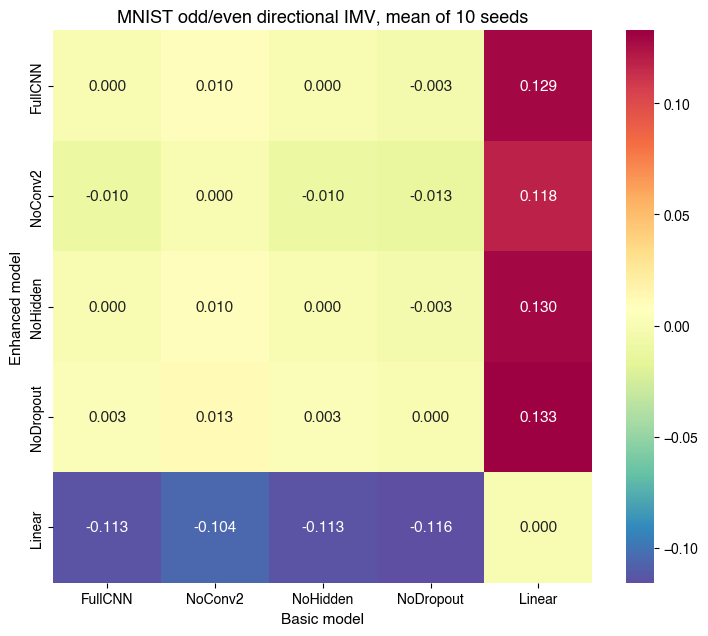

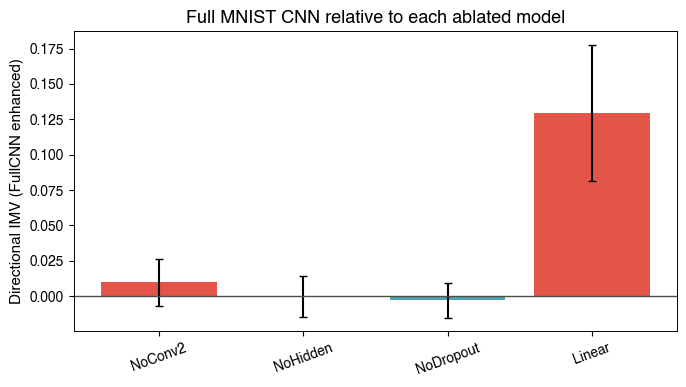

,mean,std
basic,,
NoConv2,0.009920,0.016610
NoHidden,0.000085,0.014547
NoDropout,-0.002803,0.012326
Linear,0.129437,0.048142


In [2]:
fig, ax = plot_ablation_matrix(
    mean_matrix,
    cmap=COLORMAP,
    figsize=(7.5, 6.5),
    title=f"MNIST odd/even directional IMV, mean of {len(SEEDS)} seeds",
)
ax.set_xlabel("Basic model")
ax.set_ylabel("Enhanced model")
fig.tight_layout()
matrix_paths = {file_format: relative_path(path, start=ARTIFACTS)
                for file_format, path in save_figure(
                    fig, FIGURES / "ablation_imv_mnist__ablation_imv"
                ).items()}
plt.show()

full_vs_ablation = (
    by_seed[(by_seed["enhanced"] == "FullCNN") & (by_seed["basic"] != "FullCNN")]
    .groupby("basic", sort=False)["ablation_imv"]
    .agg(["mean", "std"])
    .reindex(VARIANTS[1:])
)
full_vs_ablation.to_csv(RESULTS / "mnist_full_vs_ablation.csv")

fig2, ax2 = plt.subplots(figsize=(7, 4))
colors = [plt.get_cmap(COLORMAP)(0.85 if value >= 0 else 0.15) for value in full_vs_ablation["mean"]]
ax2.bar(
    full_vs_ablation.index,
    full_vs_ablation["mean"],
    yerr=full_vs_ablation["std"].fillna(0),
    capsize=3,
    color=colors,
)
ax2.axhline(0, color="0.3", linewidth=1)
ax2.set_ylabel("Directional IMV (FullCNN enhanced)")
ax2.set_title("Full MNIST CNN relative to each ablated model")
ax2.tick_params(axis="x", rotation=20)
fig2.tight_layout()
comparison_paths = {file_format: relative_path(path, start=ARTIFACTS)
                    for file_format, path in save_figure(
                        fig2, FIGURES / "ablation_imv_mnist__full_vs_ablation"
                    ).items()}
plt.show()
full_vs_ablation